In [2]:
from pathlib import Path
import json
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
from scipy.stats import mannwhitneyu, spearmanr
import statsmodels.formula.api as smf

HISTORY_ROOT = Path("/mnt/bulk-sirius/lizhang/LiWS/Medical_Llama_Agents/data/history/63_clean_clean_5runs")
FEATURE_DF_PATH = Path("/mnt/bulk-sirius/lizhang/LiWS/Medical_Llama_Agents/data/evaluation_logs/63/5runs/63.10/master_feature_dataframe.csv")
OUTPUT_DIR = Path("/mnt/bulk-sirius/lizhang/LiWS/Medical_Llama_Agents/data/plots/63/63.10/concept_density_posthoc")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

DIAGNOSTIC_TOOLS = {
    "request_physical_exam",
    "request_blood_test",
    "request_urine_test",
    "request_radiology",
    "request_microbiology",
}

TOOL_ITEM_KEYS = {
    "request_blood_test": "lab_values",
    "request_urine_test": "urine_values",
    "request_microbiology": "microbiology_tests",
}

UNAVAILABLE_PATTERNS = [
    "no lab result available",
    "no microbiology result available",
    "result unavailable",
    "unavailable or unmeasurable",
    "could not be performed",
    "not available",
    "not performed",
    "not found",
    "missing",
]


def setup_nm_style():
    try:
        arial_path = "/usr/share/fonts/truetype/msttcorefonts/Arial.ttf"
        fm.fontManager.addfont(arial_path)
        plt.rcParams["font.family"] = "Arial"
    except FileNotFoundError:
        plt.rcParams["font.family"] = "sans-serif"

    plt.rcParams.update({
        "font.size": 6,
        "axes.labelsize": 6,
        "axes.titlesize": 7,
        "xtick.labelsize": 5,
        "ytick.labelsize": 5,
        "legend.fontsize": 5,
        "axes.linewidth": 0.5,
        "xtick.major.width": 0.5,
        "ytick.major.width": 0.5,
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
    })


def mm_to_inches(mm):
    return mm / 25.4


def save_dual(fig, stem):
    svg_path = OUTPUT_DIR / f"{stem}.svg"
    pdf_path = OUTPUT_DIR / f"{stem}.pdf"
    fig.savefig(svg_path, format="svg", bbox_inches="tight")
    fig.savefig(pdf_path, format="pdf", bbox_inches="tight")
    print(f"Saved: {svg_path}")
    print(f"Saved: {pdf_path}")


def format_axes(ax):
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)
    ax.spines["left"].set_color("#777777")
    ax.spines["bottom"].set_color("#777777")
    ax.tick_params(axis="both", width=0.5, length=2, colors="#555555")
    ax.grid(axis="y", color="#E6E6E6", linewidth=0.5)
    ax.set_axisbelow(True)


def parse_args(arguments):
    if isinstance(arguments, dict):
        return arguments
    if isinstance(arguments, str):
        try:
            parsed = json.loads(arguments)
            return parsed if isinstance(parsed, dict) else {}
        except Exception:
            return {}
    return {}


def norm_text(x):
    return " ".join(str(x).strip().lower().split())


def parse_case_from_path(path):
    rel = path.relative_to(HISTORY_ROOT)
    run_id = int(rel.parts[0].replace("run_", ""))
    dataset = rel.parts[1]
    filename = path.name
    prefix = f"{dataset}_"
    suffix = "_conversation_"
    if filename.startswith(prefix) and suffix in filename:
        case_id = filename[len(prefix):filename.index(suffix)]
    else:
        case_id = filename.split(suffix)[0]
    return run_id, dataset, str(case_id)


def content_has_unavailable(content):
    lower = norm_text(content)
    return any(p in lower for p in UNAVAILABLE_PATTERNS)


def item_unavailable(item_name, content):
    item = re.escape(norm_text(item_name))
    content_norm = norm_text(content)

    item_patterns = [
        rf"no lab result available for {item}",
        rf"no microbiology result available for {item}",
        rf"{item}\s*:\s*result unavailable",
        rf"{item}\s*:\s*no microbiology result available",
        rf"{item}\s*:\s*no lab result available",
    ]
    return any(re.search(p, content_norm) for p in item_patterns)


def count_action_evidence(function_name, arguments, content):
    args = parse_args(arguments)
    content = content or ""

    if function_name == "request_physical_exam":
        requested = ["physical_exam"]
        retrieved = [] if content_has_unavailable(content) or not str(content).strip() else requested
        return requested, retrieved

    if function_name == "request_radiology":
        modality = norm_text(args.get("modality", "radiology"))
        region = norm_text(args.get("region", "unspecified"))
        item = f"{modality}:{region}"
        requested = [item]
        retrieved = [] if content_has_unavailable(content) else requested
        return requested, retrieved

    item_key = TOOL_ITEM_KEYS.get(function_name)
    if item_key:
        values = args.get(item_key, [])
        if isinstance(values, str):
            values = [values]
        requested = [norm_text(v) for v in values if str(v).strip()]
        retrieved = [
            item for item in requested
            if not item_unavailable(item, content)
        ]
        return requested, retrieved

    return [], []


def extract_run_evidence_counts(path):
    run_id, dataset, case_id = parse_case_from_path(path)

    with path.open("r", encoding="utf-8") as f:
        conversation = json.load(f)

    tool_calls = 0
    requested_items = []
    retrieved_items = []

    for item in conversation:
        if not isinstance(item, dict) or item.get("type") != "action":
            continue

        function_name = item.get("function")
        if function_name not in DIAGNOSTIC_TOOLS:
            continue

        tool_calls += 1
        requested, retrieved = count_action_evidence(
            function_name=function_name,
            arguments=item.get("arguments"),
            content=item.get("content"),
        )

        requested_items.extend([f"{function_name}:{x}" for x in requested])
        retrieved_items.extend([f"{function_name}:{x}" for x in retrieved])

    return {
        "run_id": run_id,
        "dataset": dataset,
        "case_id": case_id,
        "ToolCallCount": tool_calls,
        "EvidenceRequestedCount": len(requested_items),
        "EvidenceRetrievedCount": len(retrieved_items),
        "DistinctEvidenceRequestedCount": len(set(requested_items)),
        "DistinctEvidenceRetrievedCount": len(set(retrieved_items)),
        "UnavailableEvidenceCount": len(requested_items) - len(retrieved_items),
        "conversation_file": str(path),
    }


def build_evidence_counts(history_root):
    rows = [
        extract_run_evidence_counts(path)
        for path in sorted(history_root.glob("run_*/*/*_conversation_*.json"))
    ]
    run_df = pd.DataFrame(rows)

    agg = (
        run_df
        .groupby(["dataset", "case_id"], as_index=False)
        .agg(
            ToolCallCount_mean=("ToolCallCount", "mean"),
            EvidenceRequestedCount_mean=("EvidenceRequestedCount", "mean"),
            EvidenceRetrievedCount_mean=("EvidenceRetrievedCount", "mean"),
            DistinctEvidenceRequestedCount_mean=("DistinctEvidenceRequestedCount", "mean"),
            DistinctEvidenceRetrievedCount_mean=("DistinctEvidenceRetrievedCount", "mean"),
            UnavailableEvidenceCount_mean=("UnavailableEvidenceCount", "mean"),
            n_runs=("run_id", "nunique"),
        )
    )
    return run_df, agg


def normalize_case_id(x):
    if pd.isna(x):
        return ""
    s = str(x)
    return s[:-2] if s.endswith(".0") else s


run_evidence_df, case_evidence_df = build_evidence_counts(HISTORY_ROOT)
features_df = pd.read_csv(FEATURE_DF_PATH)
features_df["case_id"] = features_df["hadm_id"].apply(normalize_case_id)
features_df["dataset"] = features_df["dataset"].astype(str)

analysis_df = features_df.merge(
    case_evidence_df,
    on=["dataset", "case_id"],
    how="left",
)

analysis_df["correct"] = analysis_df["final_decision"].astype(str).str.lower().isin(["true", "1"])
analysis_df["incorrect"] = ~analysis_df["correct"]
analysis_df["correct_label"] = np.where(analysis_df["correct"], "Correct", "Incorrect")

run_evidence_df.to_csv(OUTPUT_DIR / "run_level_evidence_counts.csv", index=False)
case_evidence_df.to_csv(OUTPUT_DIR / "case_level_evidence_counts.csv", index=False)
analysis_df.to_csv(OUTPUT_DIR / "concept_density_posthoc_analysis_dataframe.csv", index=False)

analysis_df[[
    "dataset", "case_id", "final_decision", "ConceptDensity_R",
    "ToolCallCount_mean", "EvidenceRequestedCount_mean",
    "EvidenceRetrievedCount_mean", "DistinctEvidenceRetrievedCount_mean"
]].head()


,dataset,case_id,final_decision,ConceptDensity_R,ToolCallCount_mean,EvidenceRequestedCount_mean,EvidenceRetrievedCount_mean,DistinctEvidenceRetrievedCount_mean
0,appendicitis,26292478,True,0.298167,3.0,19.0,17.6,17.6
1,appendicitis,24971365,True,0.134701,3.6,19.2,13.0,13.0
2,appendicitis,27428942,True,0.337892,3.4,9.8,7.6,7.6
3,appendicitis,22235144,True,0.217565,6.2,24.6,20.0,19.8
4,appendicitis,23556345,True,0.229201,3.6,9.8,7.6,7.4


In [3]:
def zscore(s):
    s = pd.to_numeric(s, errors="coerce")
    return (s - s.mean()) / s.std(ddof=0)


stat_df = analysis_df.dropna(subset=[
    "ConceptDensity_R",
    "ToolCallCount_mean",
    "EvidenceRetrievedCount_mean",
    "final_decision",
]).copy()

correct_vals = stat_df.loc[stat_df["correct"], "ConceptDensity_R"]
incorrect_vals = stat_df.loc[~stat_df["correct"], "ConceptDensity_R"]

mw = mannwhitneyu(correct_vals, incorrect_vals, alternative="two-sided")
spearman_tool = spearmanr(stat_df["ConceptDensity_R"], stat_df["ToolCallCount_mean"], nan_policy="omit")
spearman_retrieved = spearmanr(stat_df["ConceptDensity_R"], stat_df["EvidenceRetrievedCount_mean"], nan_policy="omit")

model_df = stat_df.copy()
model_df["incorrect_int"] = model_df["incorrect"].astype(int)
model_df["ConceptDensity_R_z"] = zscore(model_df["ConceptDensity_R"])
model_df["ToolCallCount_mean_z"] = zscore(model_df["ToolCallCount_mean"])
model_df["EvidenceRetrievedCount_mean_z"] = zscore(model_df["EvidenceRetrievedCount_mean"])

fit = smf.logit(
    "incorrect_int ~ ConceptDensity_R_z + ToolCallCount_mean_z + EvidenceRetrievedCount_mean_z + C(dataset)",
    data=model_df,
).fit(disp=False)

coef = fit.params
ci = fit.conf_int()
or_table = pd.DataFrame({
    "term": coef.index,
    "coef": coef.values,
    "odds_ratio": np.exp(coef.values),
    "ci_lower": np.exp(ci[0].values),
    "ci_upper": np.exp(ci[1].values),
    "p_value": fit.pvalues.values,
})

summary_rows = [
    {
        "comparison": "ConceptDensity_R correct vs incorrect",
        "correct_median": correct_vals.median(),
        "correct_q1": correct_vals.quantile(0.25),
        "correct_q3": correct_vals.quantile(0.75),
        "incorrect_median": incorrect_vals.median(),
        "incorrect_q1": incorrect_vals.quantile(0.25),
        "incorrect_q3": incorrect_vals.quantile(0.75),
        "mannwhitney_p": mw.pvalue,
    },
    {
        "comparison": "ConceptDensity_R vs ToolCallCount_mean",
        "spearman_rho": spearman_tool.statistic,
        "spearman_p": spearman_tool.pvalue,
    },
    {
        "comparison": "ConceptDensity_R vs EvidenceRetrievedCount_mean",
        "spearman_rho": spearman_retrieved.statistic,
        "spearman_p": spearman_retrieved.pvalue,
    },
]

pd.DataFrame(summary_rows).to_csv(OUTPUT_DIR / "concept_density_posthoc_summary.csv", index=False)
or_table.to_csv(OUTPUT_DIR / "concept_density_adjusted_logistic_or.csv", index=False)

display(pd.DataFrame(summary_rows))
display(or_table)


,comparison,correct_median,correct_q1,correct_q3,incorrect_median,incorrect_q1,incorrect_q3,mannwhitney_p,spearman_rho,spearman_p
0,ConceptDensity_R correct vs incorrect,0.301758,0.262567,0.344616,0.324617,0.276881,0.353604,0.079554,NaN,NaN
1,ConceptDensity_R vs ToolCallCount_mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.131427,1.991735e-03
2,ConceptDensity_R vs EvidenceRetrievedCount_mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.266254,2.143519e-10


,term,coef,odds_ratio,ci_lower,ci_upper,p_value
0,Intercept,-4.044280,0.017522,0.005271,0.058245,4.138470e-11
1,C(dataset)[T.cholecystitis],1.803685,6.071981,1.501468,24.555274,1.140309e-02
2,C(dataset)[T.diverticulitis],1.022751,2.780834,0.526665,14.683037,2.283183e-01
3,C(dataset)[T.pancreatitis],1.370840,3.938659,0.773278,20.061403,9.885909e-02
4,C(dataset)[T.pneumonia],3.308055,27.331924,6.064520,123.181080,1.659561e-05
5,C(dataset)[T.pulmonary_embolism],1.779951,5.929565,1.486810,23.647768,1.167109e-02
6,C(dataset)[T.uti],1.518075,4.563432,0.957484,21.749616,5.672392e-02
7,ConceptDensity_R_z,-0.209770,0.810771,0.561424,1.170862,2.632589e-01
8,ToolCallCount_mean_z,0.857567,2.357419,1.622053,3.426166,6.936499e-06
9,EvidenceRetrievedCount_mean_z,-0.139755,0.869571,0.609766,1.240072,4.402596e-01


In [4]:
setup_nm_style()

palette_correct = {
    "Correct": "#5D9BB5",
    "Incorrect": "#D07B5F",
}

# Panel-style figure 1: ConceptDensity_R correct vs incorrect
fig, ax = plt.subplots(figsize=(mm_to_inches(88), 2.8), dpi=600)

sns.boxplot(
    data=analysis_df,
    x="correct_label",
    y="ConceptDensity_R",
    order=["Correct", "Incorrect"],
    palette=palette_correct,
    width=0.55,
    linewidth=0.6,
    fliersize=1.5,
    ax=ax,
)
sns.stripplot(
    data=analysis_df,
    x="correct_label",
    y="ConceptDensity_R",
    order=["Correct", "Incorrect"],
    color="#222222",
    size=1.2,
    alpha=0.18,
    jitter=0.18,
    ax=ax,
)

ax.set_title("Concept density by correctness", loc="left", fontsize=7, fontweight="bold")
ax.set_xlabel("")
ax.set_ylabel("ConceptDensity_R")
format_axes(ax)
plt.tight_layout()
save_dual(fig, "concept_density_correct_vs_incorrect")
plt.close(fig)


# Figure 2: ConceptDensity_R across retrieved evidence tertiles
plot_df = analysis_df.dropna(subset=["ConceptDensity_R", "EvidenceRetrievedCount_mean"]).copy()
plot_df["retrieved_evidence_tertile"] = pd.qcut(
    plot_df["EvidenceRetrievedCount_mean"],
    q=3,
    labels=["Low", "Medium", "High"],
    duplicates="drop",
)

fig, ax = plt.subplots(figsize=(mm_to_inches(120), 2.9), dpi=600)

sns.boxplot(
    data=plot_df,
    x="retrieved_evidence_tertile",
    y="ConceptDensity_R",
    hue="correct_label",
    hue_order=["Correct", "Incorrect"],
    palette=palette_correct,
    width=0.65,
    linewidth=0.6,
    fliersize=1.5,
    ax=ax,
)

ax.set_title("Concept density stratified by retrieved evidence", loc="left", fontsize=7, fontweight="bold")
ax.set_xlabel("Retrieved evidence burden")
ax.set_ylabel("ConceptDensity_R")
format_axes(ax)
ax.legend(title="", frameon=False, fontsize=5, loc="upper left")
plt.tight_layout()
save_dual(fig, "concept_density_by_retrieved_evidence_tertile")
plt.close(fig)


# Figure 3: ConceptDensity_R vs retrieved evidence count
fig, ax = plt.subplots(figsize=(mm_to_inches(120), 2.9), dpi=600)

sns.scatterplot(
    data=plot_df,
    x="EvidenceRetrievedCount_mean",
    y="ConceptDensity_R",
    hue="correct_label",
    hue_order=["Correct", "Incorrect"],
    palette=palette_correct,
    s=10,
    alpha=0.45,
    linewidth=0,
    ax=ax,
)

ax.set_title("Concept density vs retrieved evidence", loc="left", fontsize=7, fontweight="bold")
ax.set_xlabel("Retrieved evidence items per run, mean")
ax.set_ylabel("ConceptDensity_R")
format_axes(ax)
ax.legend(title="", frameon=False, fontsize=5, loc="upper left")
plt.tight_layout()
save_dual(fig, "concept_density_vs_retrieved_evidence_scatter")
plt.close(fig)


/tmp/ipykernel_4050305/2252216667.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


Saved: /mnt/bulk-sirius/lizhang/LiWS/Medical_Llama_Agents/data/plots/63/63.10/concept_density_posthoc/concept_density_correct_vs_incorrect.svg
Saved: /mnt/bulk-sirius/lizhang/LiWS/Medical_Llama_Agents/data/plots/63/63.10/concept_density_posthoc/concept_density_correct_vs_incorrect.pdf
Saved: /mnt/bulk-sirius/lizhang/LiWS/Medical_Llama_Agents/data/plots/63/63.10/concept_density_posthoc/concept_density_by_retrieved_evidence_tertile.svg
Saved: /mnt/bulk-sirius/lizhang/LiWS/Medical_Llama_Agents/data/plots/63/63.10/concept_density_posthoc/concept_density_by_retrieved_evidence_tertile.pdf
Saved: /mnt/bulk-sirius/lizhang/LiWS/Medical_Llama_Agents/data/plots/63/63.10/concept_density_posthoc/concept_density_vs_retrieved_evidence_scatter.svg
Saved: /mnt/bulk-sirius/lizhang/LiWS/Medical_Llama_Agents/data/plots/63/63.10/concept_density_posthoc/concept_density_vs_retrieved_evidence_scatter.pdf


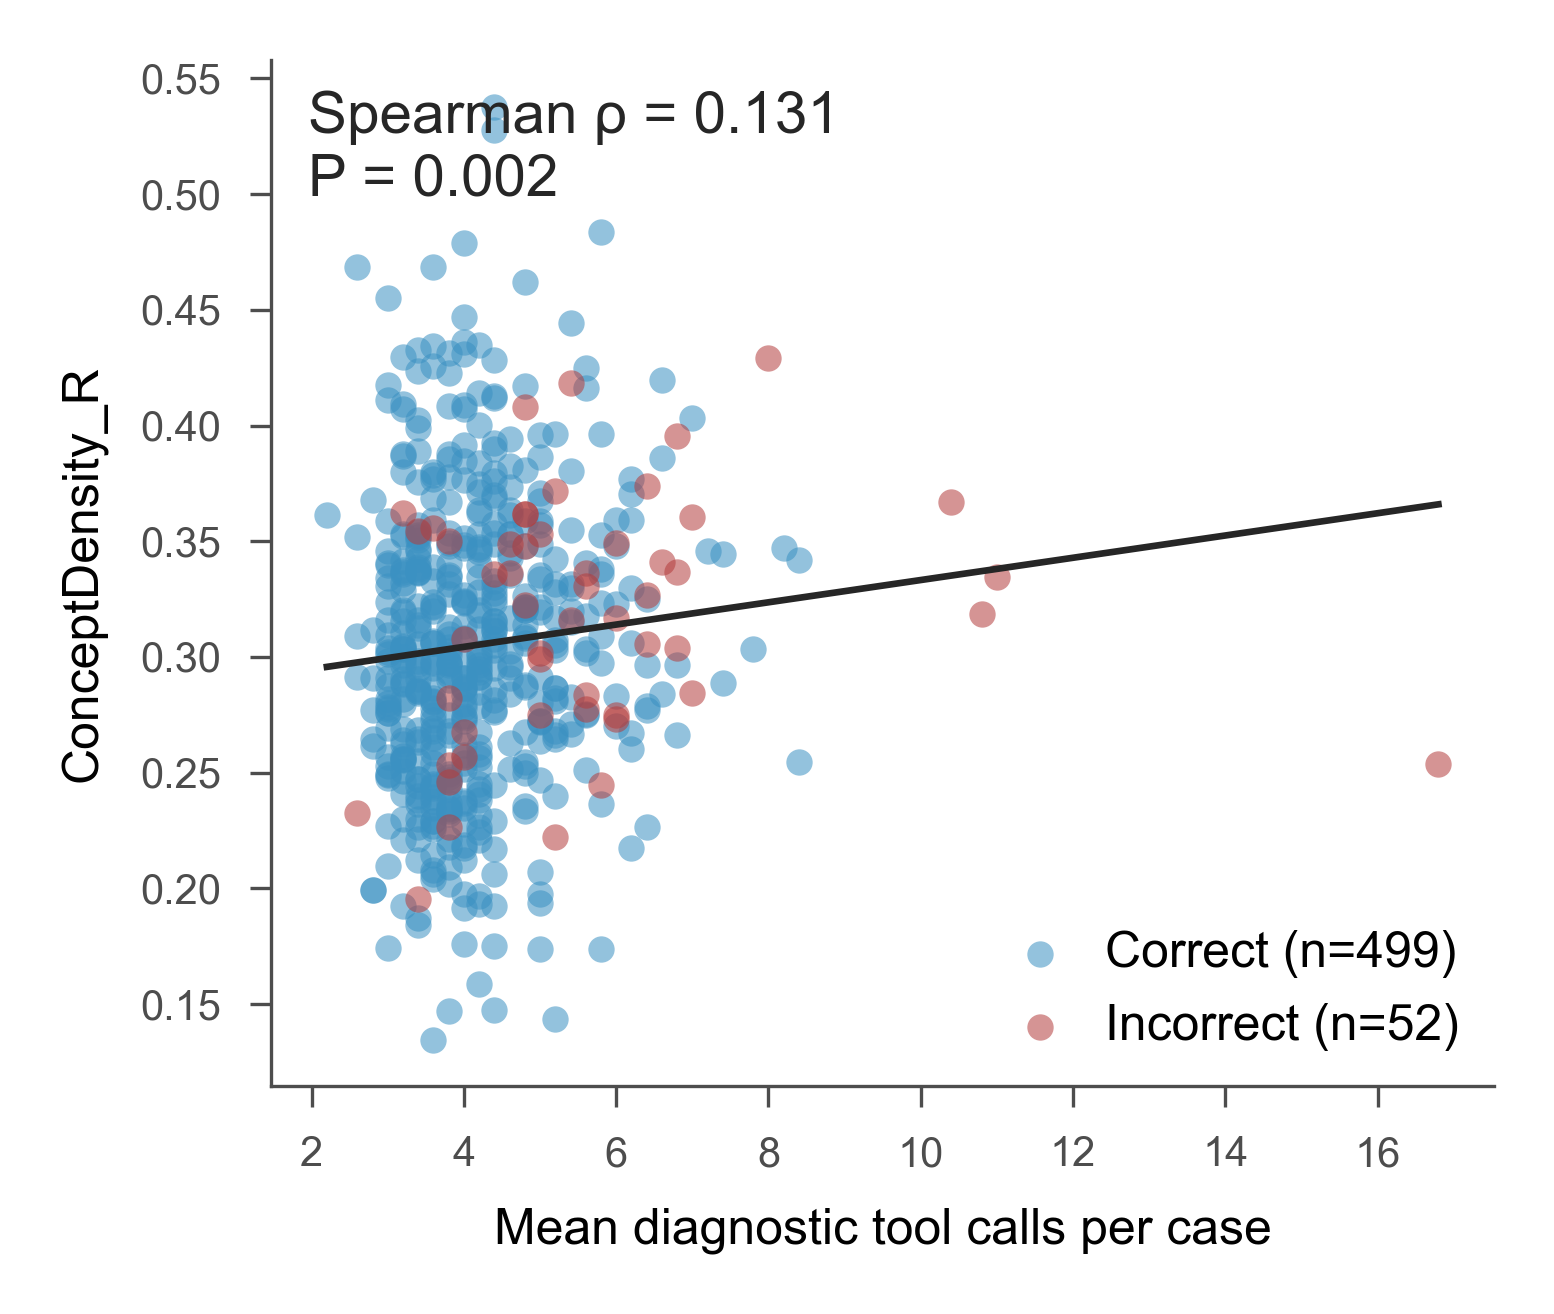

Saved: /mnt/bulk-sirius/lizhang/LiWS/Medical_Llama_Agents/data/plots/63/63.10/concept_density_posthoc/concept_density_vs_tool_call_count_scatter.pdf
Saved: /mnt/bulk-sirius/lizhang/LiWS/Medical_Llama_Agents/data/plots/63/63.10/concept_density_posthoc/concept_density_vs_tool_call_count_scatter.svg
Spearman rho = 0.131427, P = 0.00199174, n = 551


In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

# -----------------------------
# Paths
# -----------------------------
POSTHOC_DIR = "/mnt/bulk-sirius/lizhang/LiWS/Medical_Llama_Agents/data/plots/63/63.10/concept_density_posthoc"
ANALYSIS_CSV = os.path.join(POSTHOC_DIR, "concept_density_posthoc_analysis_dataframe.csv")

plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 7,
    "axes.linewidth": 0.4,
    "axes.edgecolor": "#4D4D4D",
    "xtick.color": "#4D4D4D",
    "ytick.color": "#4D4D4D",
    "xtick.major.width": 0.4,
    "ytick.major.width": 0.4,
    "xtick.major.size": 2.5,
    "ytick.major.size": 2.5,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "svg.fonttype": "none",
})

# -----------------------------
# Load data
# -----------------------------
df = pd.read_csv(ANALYSIS_CSV)

x_col = "ToolCallCount_mean"
y_col = "ConceptDensity_R"

plot_df = df[[x_col, y_col, "final_decision"]].copy()
plot_df = plot_df.replace([np.inf, -np.inf], np.nan).dropna(subset=[x_col, y_col])

# final_decision: True = correct, False = incorrect
plot_df["Correctness"] = np.where(plot_df["final_decision"].astype(bool), "Correct", "Incorrect")

rho, pval = spearmanr(plot_df[x_col], plot_df[y_col])

# -----------------------------
# Plot
# -----------------------------
fig, ax = plt.subplots(figsize=(2.6, 2.2), dpi=600)

colors = {
    "Correct": "#3B91C2",
    "Incorrect": "#B43C3C",
}

for label in ["Correct", "Incorrect"]:
    sub = plot_df[plot_df["Correctness"] == label]
    ax.scatter(
        sub[x_col],
        sub[y_col],
        s=10,
        alpha=0.55,
        linewidths=0,
        color=colors[label],
        label=f"{label} (n={len(sub)})",
        rasterized=True,
    )

# Linear trend only for visualization; statistics use Spearman correlation.
if len(plot_df) >= 2:
    x = plot_df[x_col].to_numpy(dtype=float)
    y = plot_df[y_col].to_numpy(dtype=float)
    coef = np.polyfit(x, y, deg=1)
    x_line = np.linspace(np.nanmin(x), np.nanmax(x), 100)
    y_line = coef[0] * x_line + coef[1]
    ax.plot(x_line, y_line, color="#262626", linewidth=0.8)

# Axes
ax.set_xlabel("Mean diagnostic tool calls per case")
ax.set_ylabel("ConceptDensity_R")

for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

for spine in ["left", "bottom"]:
    ax.spines[spine].set_linewidth(0.4)
    ax.spines[spine].set_color("#4D4D4D")

ax.tick_params(axis="both", direction="out", width=0.4, length=2.5)

# Annotation
if pval < 0.001:
    p_text = f"P = {pval:.1e}"
else:
    p_text = f"P = {pval:.3f}"

ax.text(
    0.03,
    0.97,
    f"Spearman ρ = {rho:.3f}\n{p_text}",
    transform=ax.transAxes,
    ha="left",
    va="top",
    fontsize=7,
    color="#262626",
)

ax.legend(
    frameon=False,
    loc="lower right",
    fontsize=6,
    handletextpad=0.3,
    borderpad=0.2,
)

plt.tight_layout()

# -----------------------------
# Save
# -----------------------------
pdf_out = os.path.join(POSTHOC_DIR, "concept_density_vs_tool_call_count_scatter.pdf")
svg_out = os.path.join(POSTHOC_DIR, "concept_density_vs_tool_call_count_scatter.svg")

fig.savefig(pdf_out, bbox_inches="tight")
fig.savefig(svg_out, bbox_inches="tight")
plt.show()

print(f"Saved: {pdf_out}")
print(f"Saved: {svg_out}")
print(f"Spearman rho = {rho:.6f}, P = {pval:.6g}, n = {len(plot_df)}")


Saved: /mnt/bulk-sirius/lizhang/LiWS/Medical_Llama_Agents/data/plots/63/63.10/concept_density_posthoc/response_fig_R1_concept_density_process_variables.pdf
Saved: /mnt/bulk-sirius/lizhang/LiWS/Medical_Llama_Agents/data/plots/63/63.10/concept_density_posthoc/response_fig_R1_concept_density_process_variables.svg


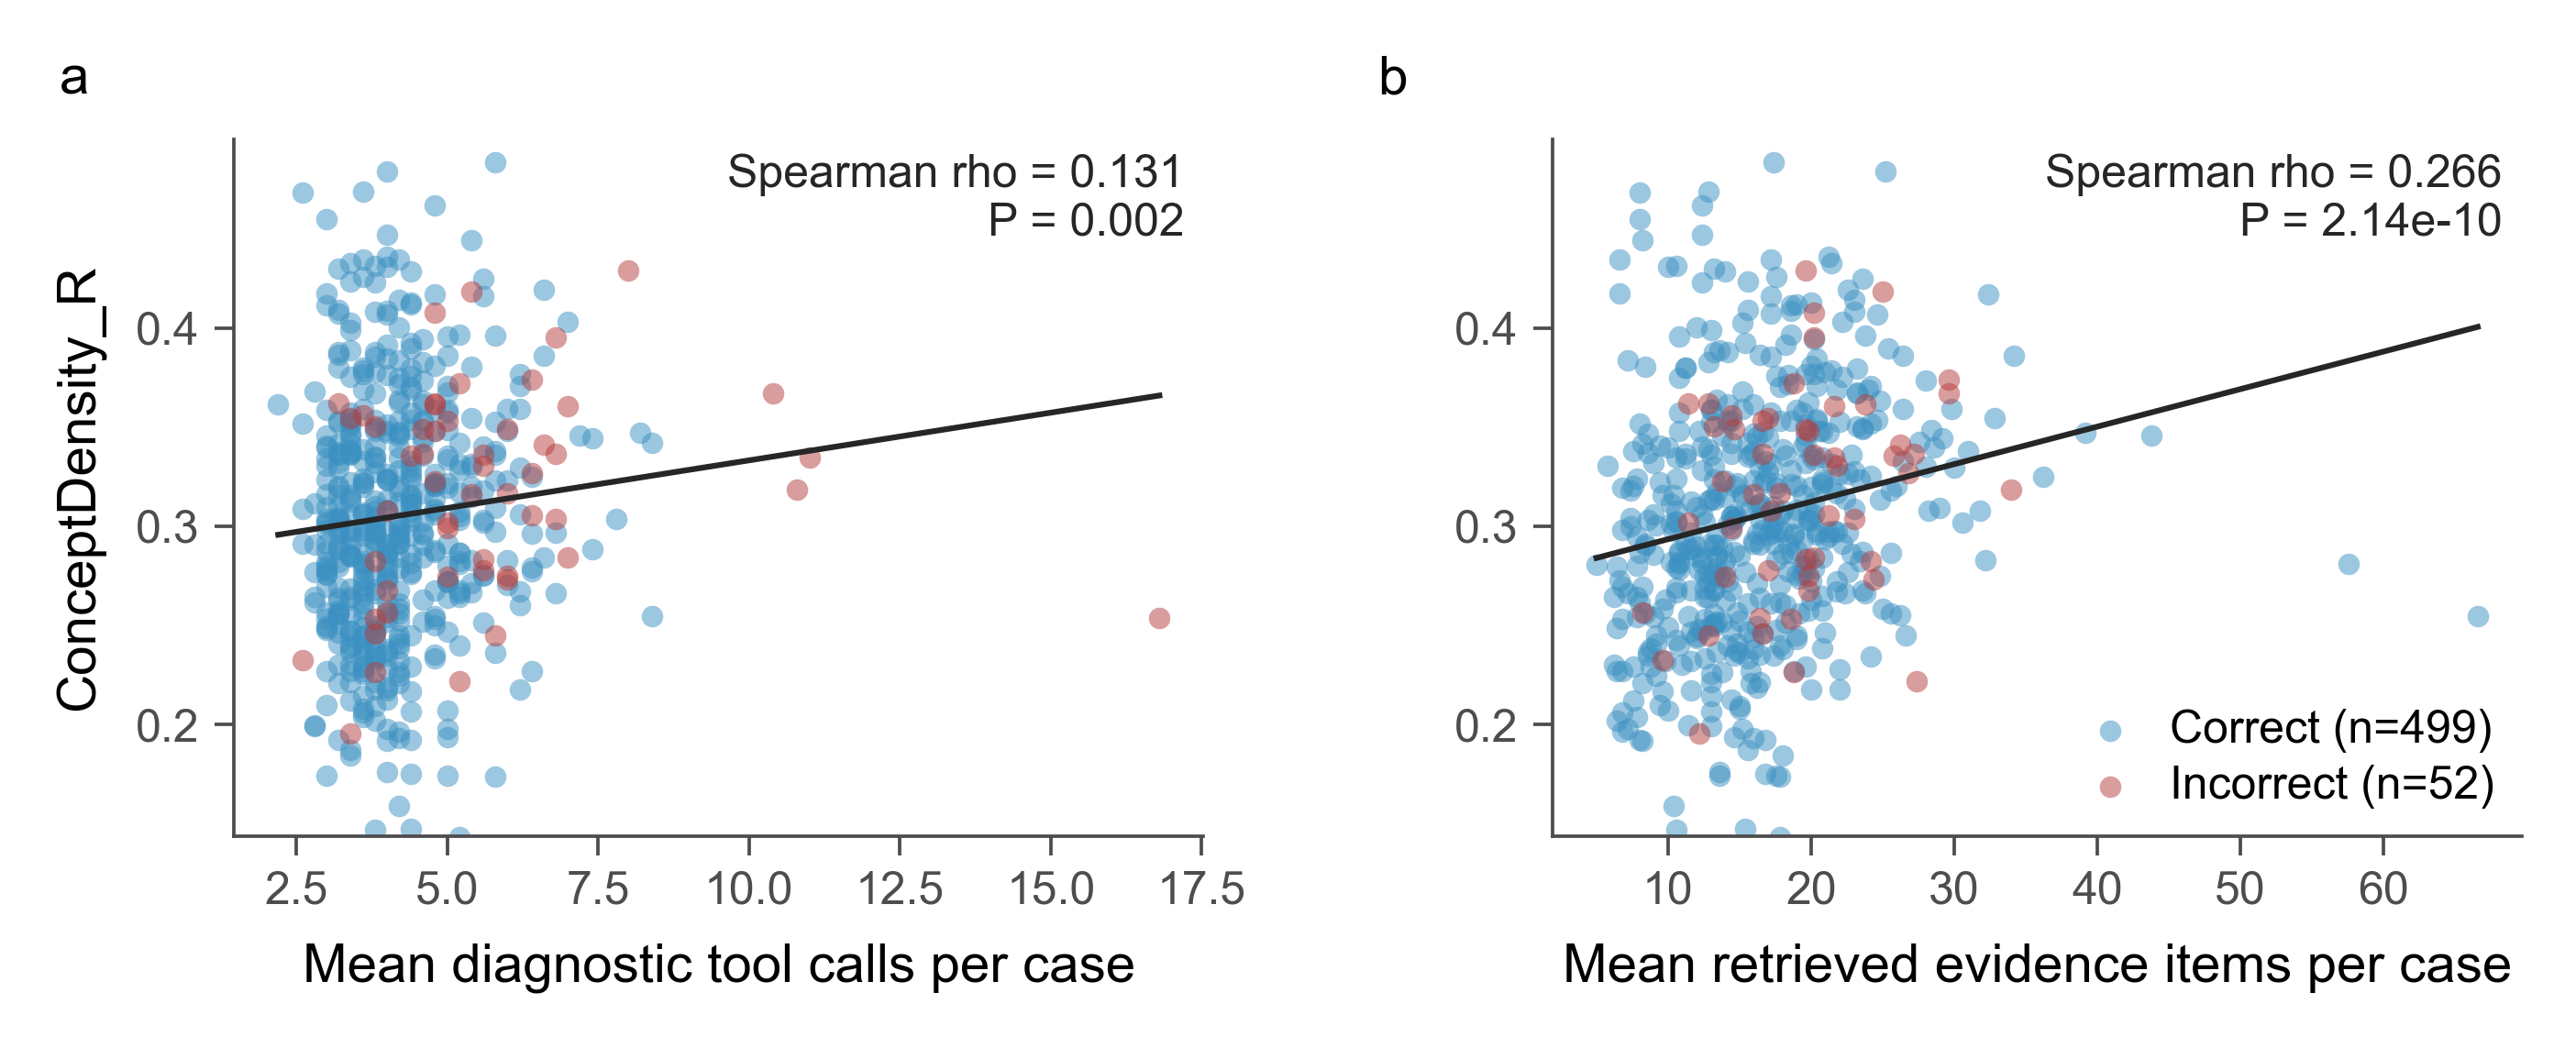

Saved: /mnt/bulk-sirius/lizhang/LiWS/Medical_Llama_Agents/data/plots/63/63.10/concept_density_posthoc/concept_density_vs_tool_call_count_nm.pdf
Saved: /mnt/bulk-sirius/lizhang/LiWS/Medical_Llama_Agents/data/plots/63/63.10/concept_density_posthoc/concept_density_vs_tool_call_count_nm.svg


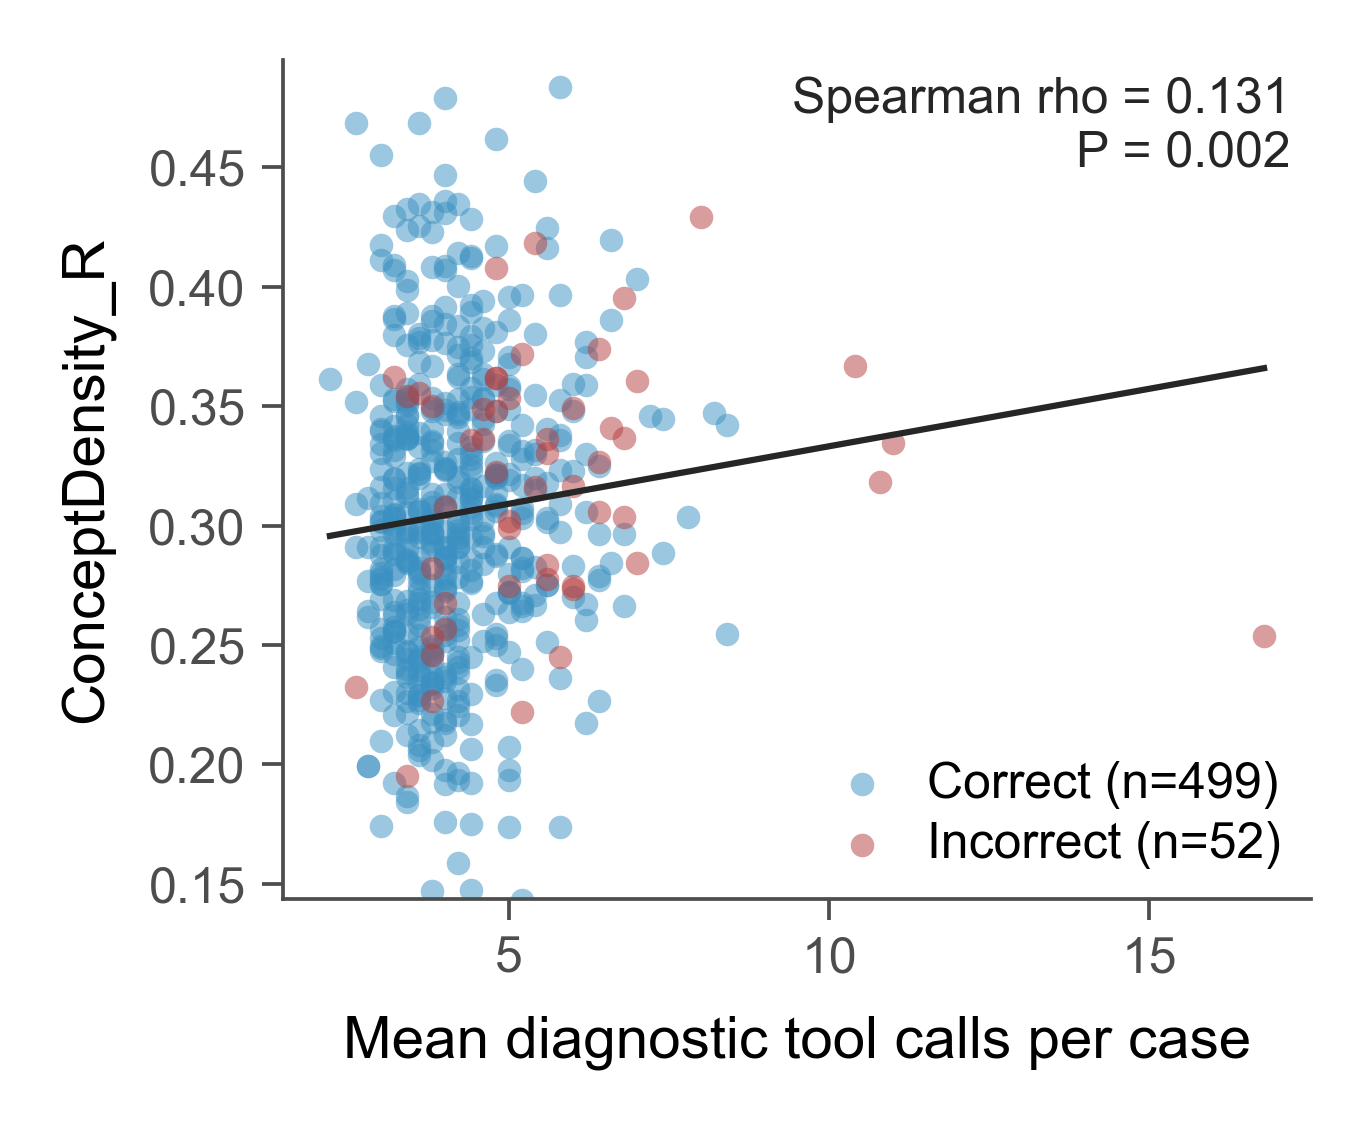

Saved: /mnt/bulk-sirius/lizhang/LiWS/Medical_Llama_Agents/data/plots/63/63.10/concept_density_posthoc/concept_density_vs_retrieved_evidence_nm.pdf
Saved: /mnt/bulk-sirius/lizhang/LiWS/Medical_Llama_Agents/data/plots/63/63.10/concept_density_posthoc/concept_density_vs_retrieved_evidence_nm.svg


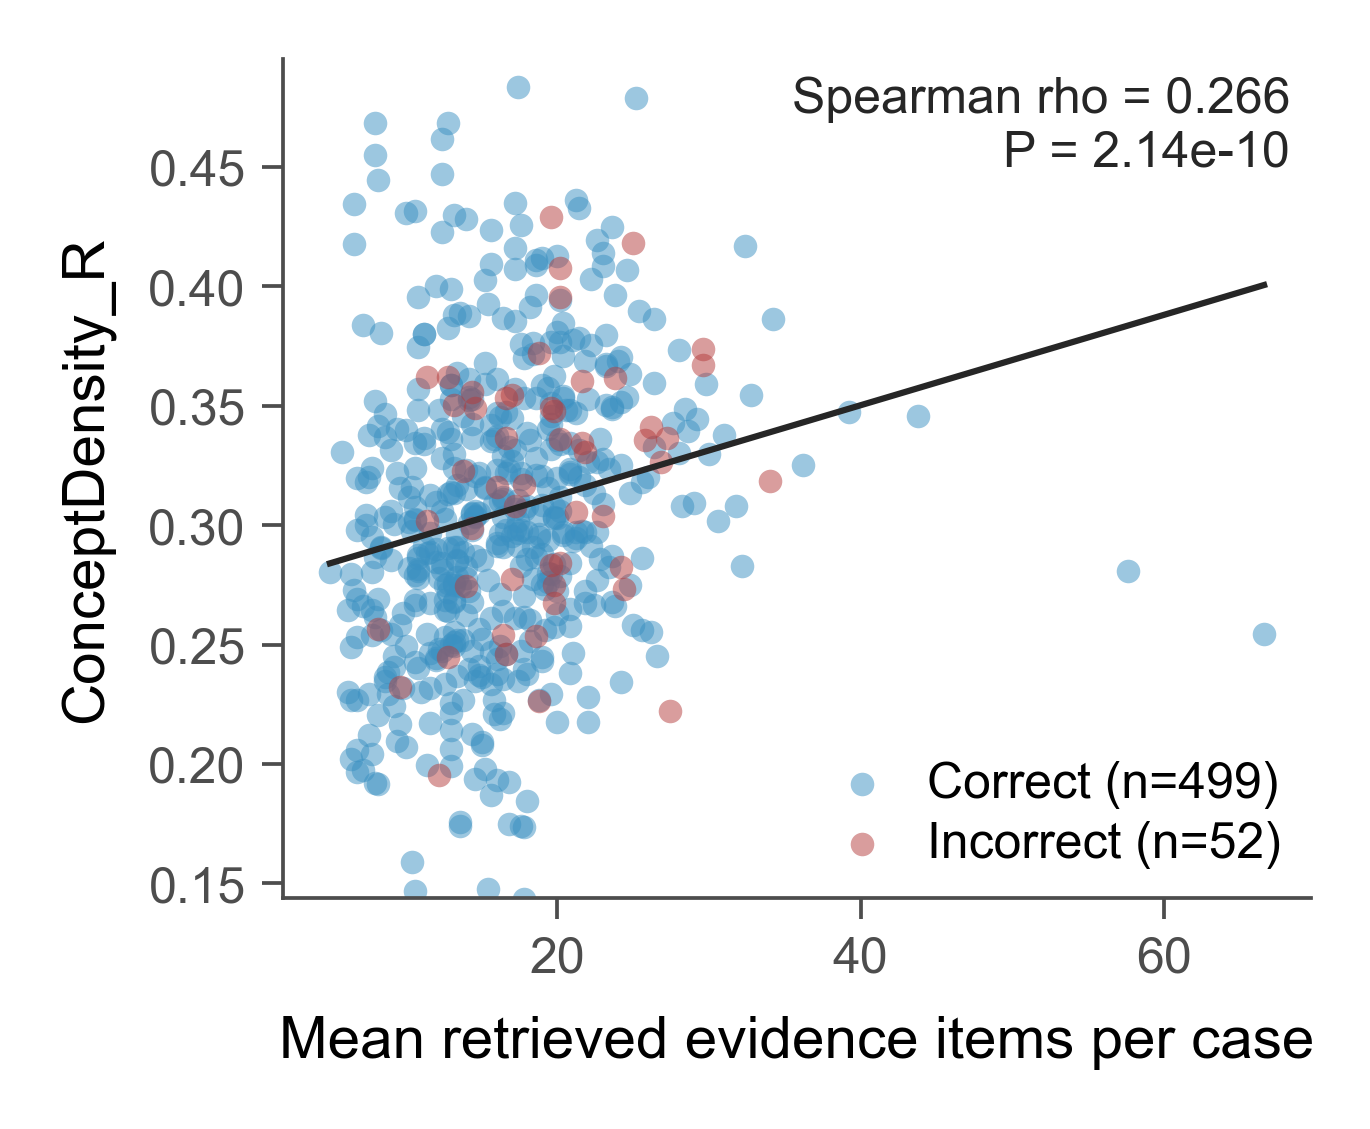


Spearman summary:
                      x_col            y_col   n  spearman_rho   spearman_p
         ToolCallCount_mean ConceptDensity_R 551      0.131427 1.991735e-03
EvidenceRetrievedCount_mean ConceptDensity_R 551      0.266254 2.143519e-10


In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

# ============================================================
# Paths
# ============================================================
POSTHOC_DIR = "/mnt/bulk-sirius/lizhang/LiWS/Medical_Llama_Agents/data/plots/63/63.10/concept_density_posthoc"
ANALYSIS_CSV = os.path.join(POSTHOC_DIR, "concept_density_posthoc_analysis_dataframe.csv")

os.makedirs(POSTHOC_DIR, exist_ok=True)

MM_TO_INCH = 1 / 25.4

plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 7,
    "axes.labelsize": 7,
    "axes.titlesize": 7,
    "xtick.labelsize": 6,
    "ytick.labelsize": 6,
    "legend.fontsize": 6,
    "axes.linewidth": 0.45,
    "axes.edgecolor": "#4D4D4D",
    "xtick.color": "#4D4D4D",
    "ytick.color": "#4D4D4D",
    "xtick.major.width": 0.45,
    "ytick.major.width": 0.45,
    "xtick.major.size": 2.5,
    "ytick.major.size": 2.5,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "svg.fonttype": "none",
    "figure.dpi": 600,
    "savefig.dpi": 600,
})

# RGB colors, muted and colorblind-tolerant enough for response figure
COLOR_CORRECT = "#3B91C2"
COLOR_INCORRECT = "#B43C3C"
COLOR_TREND = "#262626"
COLOR_AXIS = "#4D4D4D"

# ============================================================
# Helpers
# ============================================================
def format_p_value(p):
    if p < 1e-99:
        return "P < 1e-99"
    if p < 1e-3:
        return f"P = {p:.2e}"
    return f"P = {p:.3f}"


def style_axis(ax):
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)

    for spine in ["left", "bottom"]:
        ax.spines[spine].set_linewidth(0.45)
        ax.spines[spine].set_color(COLOR_AXIS)

    ax.tick_params(
        axis="both",
        which="major",
        direction="out",
        width=0.45,
        length=2.5,
        color=COLOR_AXIS,
        pad=2,
    )

    ax.grid(False)


def add_linear_visual_guide(ax, x, y):
    valid = np.isfinite(x) & np.isfinite(y)
    x = x[valid]
    y = y[valid]

    if len(x) < 3 or np.nanmax(x) == np.nanmin(x):
        return

    coef = np.polyfit(x, y, deg=1)
    x_line = np.linspace(np.nanmin(x), np.nanmax(x), 100)
    y_line = coef[0] * x_line + coef[1]

    ax.plot(
        x_line,
        y_line,
        color=COLOR_TREND,
        linewidth=0.75,
        zorder=3,
    )


def plot_cd_scatter(
    ax,
    df,
    x_col,
    y_col="ConceptDensity_R",
    x_label="",
    panel_label=None,
    show_ylabel=True,
    show_legend=False,
):
    plot_df = df[[x_col, y_col, "final_decision"]].copy()
    plot_df = plot_df.replace([np.inf, -np.inf], np.nan)
    plot_df = plot_df.dropna(subset=[x_col, y_col, "final_decision"])

    plot_df["Correctness"] = np.where(
        plot_df["final_decision"].astype(bool),
        "Correct",
        "Incorrect",
    )

    rho, pval = spearmanr(plot_df[x_col], plot_df[y_col])

    for correctness, color in [
        ("Correct", COLOR_CORRECT),
        ("Incorrect", COLOR_INCORRECT),
    ]:
        sub = plot_df[plot_df["Correctness"] == correctness]

        ax.scatter(
            sub[x_col],
            sub[y_col],
            s=8,
            color=color,
            alpha=0.50,
            linewidths=0,
            label=f"{correctness} (n={len(sub)})",
            zorder=2,
        )

    add_linear_visual_guide(
        ax,
        plot_df[x_col].to_numpy(dtype=float),
        plot_df[y_col].to_numpy(dtype=float),
    )

    style_axis(ax)

    ax.set_xlabel(x_label)
    if show_ylabel:
        ax.set_ylabel("ConceptDensity_R")
    else:
        ax.set_ylabel("")

    # Conservative y-limits with small padding
    y = plot_df[y_col].to_numpy(dtype=float)
    y_min = max(0, np.nanpercentile(y, 1) - 0.03)
    y_max = min(1, np.nanpercentile(y, 99) + 0.03)
    if y_max <= y_min:
        y_min, y_max = np.nanmin(y), np.nanmax(y)
    ax.set_ylim(y_min, y_max)

    # x-limits with padding
    x = plot_df[x_col].to_numpy(dtype=float)
    x_pad = max((np.nanmax(x) - np.nanmin(x)) * 0.05, 0.2)
    ax.set_xlim(np.nanmin(x) - x_pad, np.nanmax(x) + x_pad)

    stat_text = f"Spearman rho = {rho:.3f}\n{format_p_value(pval)}"
    ax.text(
        0.98,
        0.98,
        stat_text,
        transform=ax.transAxes,
        ha="right",
        va="top",
        fontsize=6,
        color="#262626",
        bbox=dict(
            facecolor="white",
            edgecolor="none",
            alpha=0.75,
            pad=1.5,
        ),
    )


    if panel_label is not None:
        ax.text(
            -0.18,
            1.05,
            panel_label,
            transform=ax.transAxes,
            ha="left",
            va="bottom",
            fontsize=7,
            fontweight="bold",
            color="#000000",
        )

    if show_legend:
        ax.legend(
            frameon=False,
            loc="lower right",
            handletextpad=0.3,
            borderpad=0.1,
            labelspacing=0.25,
            markerscale=1.0,
        )

    return {
        "x_col": x_col,
        "y_col": y_col,
        "n": len(plot_df),
        "spearman_rho": rho,
        "spearman_p": pval,
    }


def save_pdf_svg(fig, base_path):
    pdf_path = f"{base_path}.pdf"
    svg_path = f"{base_path}.svg"

    fig.savefig(pdf_path, bbox_inches="tight")
    fig.savefig(svg_path, bbox_inches="tight")

    print(f"Saved: {pdf_path}")
    print(f"Saved: {svg_path}")


# ============================================================
# Load data
# ============================================================
df = pd.read_csv(ANALYSIS_CSV)

required_cols = {
    "ConceptDensity_R",
    "ToolCallCount_mean",
    "EvidenceRetrievedCount_mean",
    "final_decision",
}
missing = required_cols - set(df.columns)
if missing:
    raise ValueError(f"Missing required columns: {sorted(missing)}")

source_cols = [
    col for col in [
        "dataset",
        "case_id",
        "final_decision",
        "ConceptDensity_R",
        "ToolCallCount_mean",
        "EvidenceRetrievedCount_mean",
    ]
    if col in df.columns
]

df[source_cols].to_csv(
    os.path.join(POSTHOC_DIR, "response_fig_R1_source_data.csv"),
    index=False,
)

# ============================================================
# Combined two-panel Response Figure R1
# Width: 180 mm max two-column; use ~120 mm for compact rebuttal figure
# ============================================================
fig, axes = plt.subplots(
    1,
    2,
    figsize=(120 * MM_TO_INCH, 48 * MM_TO_INCH),
    dpi=600,
    constrained_layout=False,
)

summary_rows = []

summary_rows.append(
    plot_cd_scatter(
        axes[0],
        df,
        x_col="ToolCallCount_mean",
        x_label="Mean diagnostic tool calls per case",
        panel_label="a",
        show_ylabel=True,
        show_legend=False,
    )
)

summary_rows.append(
    plot_cd_scatter(
        axes[1],
        df,
        x_col="EvidenceRetrievedCount_mean",
        x_label="Mean retrieved evidence items per case",
        panel_label="b",
        show_ylabel=False,
        show_legend=True,
    )
)

fig.subplots_adjust(
    left=0.10,
    right=0.98,
    bottom=0.23,
    top=0.90,
    wspace=0.36,
)

save_pdf_svg(
    fig,
    os.path.join(POSTHOC_DIR, "response_fig_R1_concept_density_process_variables"),
)

plt.show()

# ============================================================
# Standalone panel: ToolCallCount
# Size: near one-column width, compact
# ============================================================
fig_tool, ax_tool = plt.subplots(
    figsize=(58 * MM_TO_INCH, 48 * MM_TO_INCH),
    dpi=600,
)

tool_summary = plot_cd_scatter(
    ax_tool,
    df,
    x_col="ToolCallCount_mean",
    x_label="Mean diagnostic tool calls per case",
    panel_label=None,
    show_ylabel=True,
    show_legend=True,
)

fig_tool.subplots_adjust(
    left=0.22,
    right=0.97,
    bottom=0.22,
    top=0.96,
)

save_pdf_svg(
    fig_tool,
    os.path.join(POSTHOC_DIR, "concept_density_vs_tool_call_count_nm"),
)

plt.show()

# ============================================================
# Standalone panel: EvidenceRetrievedCount
# Size: near one-column width, compact
# ============================================================
fig_evd, ax_evd = plt.subplots(
    figsize=(58 * MM_TO_INCH, 48 * MM_TO_INCH),
    dpi=600,
)

evidence_summary = plot_cd_scatter(
    ax_evd,
    df,
    x_col="EvidenceRetrievedCount_mean",
    x_label="Mean retrieved evidence items per case",
    panel_label=None,
    show_ylabel=True,
    show_legend=True,
)

fig_evd.subplots_adjust(
    left=0.22,
    right=0.97,
    bottom=0.22,
    top=0.96,
)

save_pdf_svg(
    fig_evd,
    os.path.join(POSTHOC_DIR, "concept_density_vs_retrieved_evidence_nm"),
)

plt.show()

# ============================================================
# Save summary stats
# ============================================================
summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv(
    os.path.join(POSTHOC_DIR, "response_fig_R1_spearman_summary.csv"),
    index=False,
)

print("\nSpearman summary:")
print(summary_df.to_string(index=False))


findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.


Extracted lengths from 2755 conversation files.
        dataset   hadm_id    run  DiagnosisWordCount  DiagnosisTokenCount  \
0  appendicitis  20046307  run_1                   2                  5.0   
1  appendicitis  20095162  run_1                   5                  8.0   
2  appendicitis  20152597  run_1                   2                  4.0   
3  appendicitis  20174907  run_1                   2                  4.0   
4  appendicitis  20275614  run_1                   4                  9.0   

   ReasoningWordCount  ReasoningTokenCount  
0                  56                 73.0  
1                  71                100.0  
2                  42                 73.0  
3                  40                 62.0  
4                  46                 72.0  
Merged dataframe rows: 551
Missing DiagnosisTokenCount_mean: 0
Missing ReasoningWordCount_mean: 0

Spearman summary:
                                  analysis            metric               length_col   n  spearman_rh

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

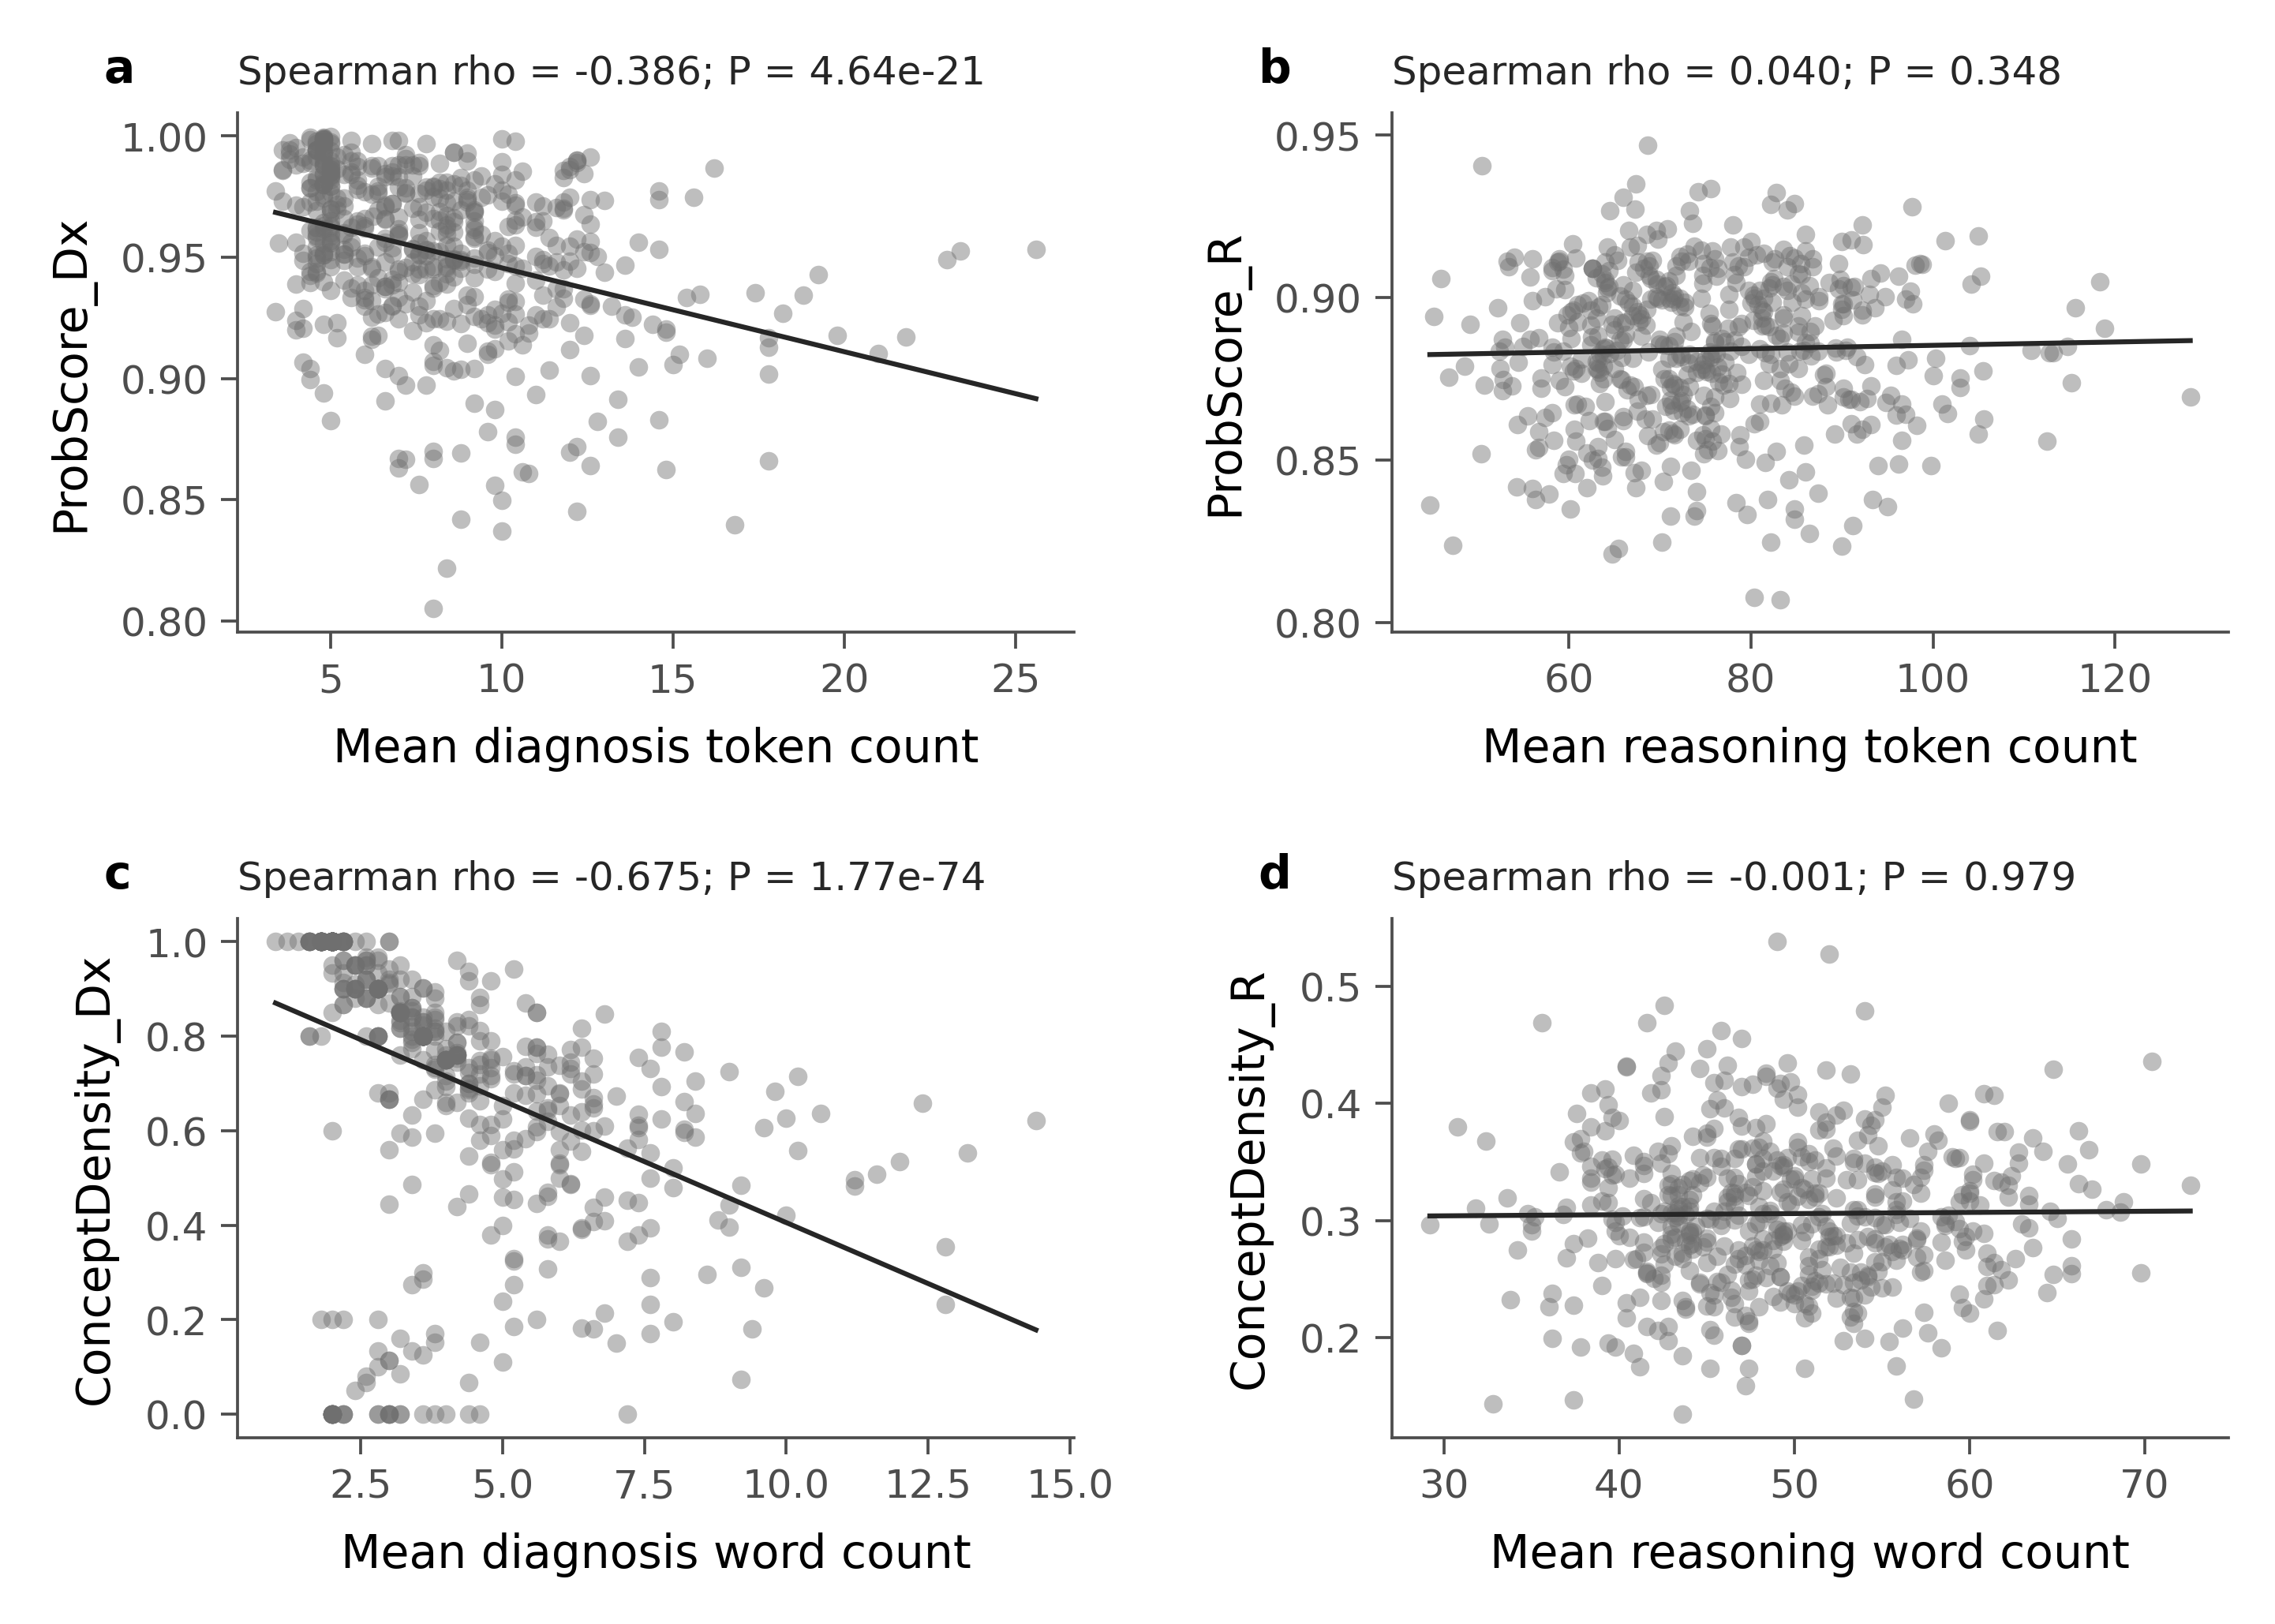

Saved: /mnt/bulk-sirius/lizhang/LiWS/Medical_Llama_Agents/data/plots/63/63.10/length_sensitivity/response_fig_R2_length_sensitivity.pdf
Saved: /mnt/bulk-sirius/lizhang/LiWS/Medical_Llama_Agents/data/plots/63/63.10/length_sensitivity/response_fig_R2_length_sensitivity.svg

Output files:
/mnt/bulk-sirius/lizhang/LiWS/Medical_Llama_Agents/data/plots/63/63.10/length_sensitivity/run_level_output_lengths.csv
/mnt/bulk-sirius/lizhang/LiWS/Medical_Llama_Agents/data/plots/63/63.10/length_sensitivity/case_level_output_lengths.csv
/mnt/bulk-sirius/lizhang/LiWS/Medical_Llama_Agents/data/plots/63/63.10/length_sensitivity/length_sensitivity_analysis_dataframe.csv
/mnt/bulk-sirius/lizhang/LiWS/Medical_Llama_Agents/data/plots/63/63.10/length_sensitivity/length_sensitivity_spearman_summary.csv
/mnt/bulk-sirius/lizhang/LiWS/Medical_Llama_Agents/data/plots/63/63.10/length_sensitivity/length_adjusted_logistic_or.csv
/mnt/bulk-sirius/lizhang/LiWS/Medical_Llama_Agents/data/plots/63/63.10/length_sensitivity/

In [ ]:
import os
import re
import json
import math
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

import statsmodels.api as sm


# ============================================================
# Paths
# ============================================================
FEATURE_CSV = "/mnt/bulk-sirius/lizhang/LiWS/Medical_Llama_Agents/data/evaluation_logs/63/5runs/63.10/master_feature_dataframe.csv"
HISTORY_ROOT = "/mnt/bulk-sirius/lizhang/LiWS/Medical_Llama_Agents/data/history/63_clean_clean_5runs"
OUTPUT_DIR = "/mnt/bulk-sirius/lizhang/LiWS/Medical_Llama_Agents/data/plots/63/63.10/length_sensitivity"

os.makedirs(OUTPUT_DIR, exist_ok=True)


MM_TO_INCH = 1 / 25.4

plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 7,
    "axes.labelsize": 7,
    "axes.titlesize": 7,
    "xtick.labelsize": 6,
    "ytick.labelsize": 6,
    "legend.fontsize": 6,
    "axes.linewidth": 0.45,
    "axes.edgecolor": "#4D4D4D",
    "xtick.color": "#4D4D4D",
    "ytick.color": "#4D4D4D",
    "xtick.major.width": 0.45,
    "ytick.major.width": 0.45,
    "xtick.major.size": 2.5,
    "ytick.major.size": 2.5,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "svg.fonttype": "none",
    "figure.dpi": 600,
    "savefig.dpi": 600,
})

COLOR_POINT = "#6F6F6F"
COLOR_TREND = "#262626"
COLOR_AXIS = "#4D4D4D"


# ============================================================
# Text / JSON helpers
# ============================================================
def word_count(text):
    if not isinstance(text, str):
        return np.nan
    words = re.findall(r"\b[\w'-]+\b", text)
    return len(words)


def safe_json_load(path):
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)


def parse_case_from_path(path):
    path = Path(path)
    dataset = path.parent.name
    run = path.parent.parent.name

    match = re.search(r"_(\d+)_conversation_\d+\.json$", path.name)
    if match:
        hadm_id = match.group(1)
    else:
        hadm_id = path.stem

    return {
        "dataset": dataset,
        "run": run,
        "hadm_id": str(hadm_id),
        "conversation_path": str(path),
    }


def parse_arguments(raw_args):
    if isinstance(raw_args, dict):
        return raw_args
    if isinstance(raw_args, str):
        try:
            return json.loads(raw_args)
        except Exception:
            return {}
    return {}


def find_finish_arguments(messages):
    """
    Prefer the explicit finish action. Fall back to logprob_analysis arguments.
    """
    if not isinstance(messages, list):
        return {}

    for msg in reversed(messages):
        if not isinstance(msg, dict):
            continue
        if msg.get("function") == "finish" and "arguments" in msg:
            args = parse_arguments(msg.get("arguments"))
            if args:
                return args

    for msg in reversed(messages):
        if not isinstance(msg, dict):
            continue
        if msg.get("type") == "logprob_analysis" and msg.get("function") == "finish":
            args = parse_arguments(msg.get("arguments"))
            if args:
                return args

    return {}


def find_logprob_analysis(messages):
    """
    Returns the final logprob analysis block, if present.
    Expected structure:
    msg["analysis"]["diagnosis"]["tokens"]
    msg["analysis"]["reasoning"]["tokens"]
    """
    if not isinstance(messages, list):
        return {}

    for msg in reversed(messages):
        if not isinstance(msg, dict):
            continue
        if msg.get("type") == "logprob_analysis" and isinstance(msg.get("analysis"), dict):
            return msg["analysis"]

    return {}


def count_analysis_tokens(analysis, stream):
    """
    stream: "diagnosis" or "reasoning"
    """
    block = analysis.get(stream, {}) if isinstance(analysis, dict) else {}
    tokens = block.get("tokens", None) if isinstance(block, dict) else None

    if isinstance(tokens, list):
        return len(tokens)

    return np.nan


def extract_lengths_from_conversation(path):
    meta = parse_case_from_path(path)

    try:
        messages = safe_json_load(path)
    except Exception as exc:
        return {
            **meta,
            "DiagnosisText": "",
            "ReasoningText": "",
            "DiagnosisWordCount": np.nan,
            "ReasoningWordCount": np.nan,
            "DiagnosisTokenCount": np.nan,
            "ReasoningTokenCount": np.nan,
            "parse_error": str(exc),
        }

    finish_args = find_finish_arguments(messages)
    analysis = find_logprob_analysis(messages)

    diagnosis_text = finish_args.get("diagnosis", "")
    reasoning_text = finish_args.get("reasoning", "")

    diagnosis_token_count = count_analysis_tokens(analysis, "diagnosis")
    reasoning_token_count = count_analysis_tokens(analysis, "reasoning")

    return {
        **meta,
        "DiagnosisText": diagnosis_text,
        "ReasoningText": reasoning_text,
        "DiagnosisWordCount": word_count(diagnosis_text),
        "ReasoningWordCount": word_count(reasoning_text),
        "DiagnosisTokenCount": diagnosis_token_count,
        "ReasoningTokenCount": reasoning_token_count,
        "parse_error": "",
    }


# ============================================================
# Extract per-run length data
# ============================================================
conversation_paths = sorted(Path(HISTORY_ROOT).glob("run_*/*/*conversation_*.json"))

if not conversation_paths:
    raise FileNotFoundError(f"No conversation JSON files found under: {HISTORY_ROOT}")

length_rows = []
for path in conversation_paths:
    length_rows.append(extract_lengths_from_conversation(path))

df_lengths_run = pd.DataFrame(length_rows)

df_lengths_run.to_csv(
    os.path.join(OUTPUT_DIR, "run_level_output_lengths.csv"),
    index=False,
)

print(f"Extracted lengths from {len(df_lengths_run)} conversation files.")
print(df_lengths_run[[
    "dataset",
    "hadm_id",
    "run",
    "DiagnosisWordCount",
    "DiagnosisTokenCount",
    "ReasoningWordCount",
    "ReasoningTokenCount",
]].head())


# ============================================================
# Aggregate to case level
# ============================================================
length_numeric_cols = [
    "DiagnosisWordCount",
    "DiagnosisTokenCount",
    "ReasoningWordCount",
    "ReasoningTokenCount",
]

df_lengths_case = (
    df_lengths_run
    .groupby(["dataset", "hadm_id"], as_index=False)
    .agg(
        n_runs_with_length=("run", "nunique"),
        DiagnosisWordCount_mean=("DiagnosisWordCount", "mean"),
        DiagnosisWordCount_median=("DiagnosisWordCount", "median"),
        DiagnosisTokenCount_mean=("DiagnosisTokenCount", "mean"),
        DiagnosisTokenCount_median=("DiagnosisTokenCount", "median"),
        ReasoningWordCount_mean=("ReasoningWordCount", "mean"),
        ReasoningWordCount_median=("ReasoningWordCount", "median"),
        ReasoningTokenCount_mean=("ReasoningTokenCount", "mean"),
        ReasoningTokenCount_median=("ReasoningTokenCount", "median"),
    )
)

df_lengths_case.to_csv(
    os.path.join(OUTPUT_DIR, "case_level_output_lengths.csv"),
    index=False,
)


# ============================================================
# Load features and merge
# ============================================================
df_feat = pd.read_csv(FEATURE_CSV)
df_feat["hadm_id"] = df_feat["hadm_id"].astype(str)
df_feat["dataset"] = df_feat["dataset"].astype(str)

df_analysis = df_feat.merge(
    df_lengths_case,
    on=["dataset", "hadm_id"],
    how="left",
    validate="one_to_one",
)

if "final_decision" not in df_analysis.columns:
    raise ValueError("final_decision column is required in feature dataframe.")

df_analysis["correct"] = df_analysis["final_decision"].astype(bool)
df_analysis["incorrect"] = (~df_analysis["correct"]).astype(int)

df_analysis.to_csv(
    os.path.join(OUTPUT_DIR, "length_sensitivity_analysis_dataframe.csv"),
    index=False,
)

print(f"Merged dataframe rows: {len(df_analysis)}")
print(f"Missing DiagnosisTokenCount_mean: {df_analysis['DiagnosisTokenCount_mean'].isna().sum()}")
print(f"Missing ReasoningWordCount_mean: {df_analysis['ReasoningWordCount_mean'].isna().sum()}")


# ============================================================
# Spearman correlation analysis
# ============================================================
ANALYSES = [
    {
        "metric": "ProbScore_Dx",
        "length_col": "DiagnosisTokenCount_mean",
        "x_label": "Mean diagnosis token count",
        "y_label": "ProbScore_Dx",
        "panel": "a",
        "interpretation": "ProbScore_Dx vs diagnosis token length",
    },
    {
        "metric": "ProbScore_R",
        "length_col": "ReasoningTokenCount_mean",
        "x_label": "Mean reasoning token count",
        "y_label": "ProbScore_R",
        "panel": "b",
        "interpretation": "ProbScore_R vs reasoning token length",
    },
    {
        "metric": "ConceptDensity_Dx",
        "length_col": "DiagnosisWordCount_mean",
        "x_label": "Mean diagnosis word count",
        "y_label": "ConceptDensity_Dx",
        "panel": "c",
        "interpretation": "ConceptDensity_Dx vs diagnosis text length",
    },
    {
        "metric": "ConceptDensity_R",
        "length_col": "ReasoningWordCount_mean",
        "x_label": "Mean reasoning word count",
        "y_label": "ConceptDensity_R",
        "panel": "d",
        "interpretation": "ConceptDensity_R vs reasoning text length",
    },
]


spearman_rows = []

for item in ANALYSES:
    metric = item["metric"]
    length_col = item["length_col"]

    sub = df_analysis[[metric, length_col]].replace([np.inf, -np.inf], np.nan).dropna()
    rho, pval = spearmanr(sub[length_col], sub[metric])

    spearman_rows.append({
        "analysis": item["interpretation"],
        "metric": metric,
        "length_col": length_col,
        "n": len(sub),
        "spearman_rho": rho,
        "spearman_p": pval,
    })

df_spearman = pd.DataFrame(spearman_rows)
df_spearman.to_csv(
    os.path.join(OUTPUT_DIR, "length_sensitivity_spearman_summary.csv"),
    index=False,
)

print("\nSpearman summary:")
print(df_spearman.to_string(index=False))


# ============================================================
# Length-adjusted logistic regression
# incorrect ~ metric + length
# No dataset adjustment.
# Predictors are standardized, so ORs are per 1 SD.
# ============================================================
def zscore(series):
    series = pd.to_numeric(series, errors="coerce")
    sd = series.std(ddof=0)
    if sd == 0 or not np.isfinite(sd):
        return series * np.nan
    return (series - series.mean()) / sd


def fit_length_adjusted_logistic(df, metric, length_col, outcome_col="incorrect"):
    cols = [outcome_col, metric, length_col]
    sub = df[cols].replace([np.inf, -np.inf], np.nan).dropna().copy()

    sub[f"{metric}_z"] = zscore(sub[metric])
    sub[f"{length_col}_z"] = zscore(sub[length_col])

    model_df = sub[[outcome_col, f"{metric}_z", f"{length_col}_z"]].dropna().copy()

    y = model_df[outcome_col].astype(int)
    X = model_df[[f"{metric}_z", f"{length_col}_z"]]
    X = sm.add_constant(X)

    try:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            model = sm.Logit(y, X).fit(disp=False, maxiter=200)

        params = model.params
        conf = model.conf_int()
        pvals = model.pvalues

        rows = []
        for term in params.index:
            rows.append({
                "model": f"incorrect ~ {metric} + {length_col}",
                "metric": metric,
                "length_col": length_col,
                "term": term,
                "n": int(model.nobs),
                "coef": params[term],
                "odds_ratio": math.exp(params[term]),
                "ci_lower": math.exp(conf.loc[term, 0]),
                "ci_upper": math.exp(conf.loc[term, 1]),
                "p_value": pvals[term],
                "converged": bool(model.mle_retvals.get("converged", True)),
            })

        return rows

    except Exception as exc:
        return [{
            "model": f"incorrect ~ {metric} + {length_col}",
            "metric": metric,
            "length_col": length_col,
            "term": "MODEL_FAILED",
            "n": len(model_df),
            "coef": np.nan,
            "odds_ratio": np.nan,
            "ci_lower": np.nan,
            "ci_upper": np.nan,
            "p_value": np.nan,
            "converged": False,
            "error": str(exc),
        }]


logistic_rows = []
for item in ANALYSES:
    logistic_rows.extend(
        fit_length_adjusted_logistic(
            df_analysis,
            metric=item["metric"],
            length_col=item["length_col"],
            outcome_col="incorrect",
        )
    )

df_logistic = pd.DataFrame(logistic_rows)
df_logistic.to_csv(
    os.path.join(OUTPUT_DIR, "length_adjusted_logistic_or.csv"),
    index=False,
)

print("\nLength-adjusted logistic regression:")
print(df_logistic.to_string(index=False))


# ============================================================
# Plot helpers
# ============================================================
def format_p_value(p):
    if not np.isfinite(p):
        return "P = NA"
    if p < 1e-3:
        return f"P = {p:.2e}"
    return f"P = {p:.3f}"


def style_axis(ax):
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)

    for spine in ["left", "bottom"]:
        ax.spines[spine].set_linewidth(0.45)
        ax.spines[spine].set_color(COLOR_AXIS)

    ax.tick_params(
        axis="both",
        which="major",
        direction="out",
        width=0.45,
        length=2.5,
        color=COLOR_AXIS,
        pad=2,
    )

    ax.grid(False)


def add_linear_visual_guide(ax, x, y):
    valid = np.isfinite(x) & np.isfinite(y)
    x = x[valid]
    y = y[valid]

    if len(x) < 3 or np.nanmax(x) == np.nanmin(x):
        return

    coef = np.polyfit(x, y, deg=1)
    x_line = np.linspace(np.nanmin(x), np.nanmax(x), 100)
    y_line = coef[0] * x_line + coef[1]

    ax.plot(
        x_line,
        y_line,
        color=COLOR_TREND,
        linewidth=0.75,
        zorder=3,
    )


def plot_length_sensitivity_panel(ax, df, metric, length_col, x_label, y_label, panel):
    plot_df = df[[metric, length_col]].replace([np.inf, -np.inf], np.nan).dropna().copy()

    x = plot_df[length_col].to_numpy(dtype=float)
    y = plot_df[metric].to_numpy(dtype=float)

    rho, pval = spearmanr(x, y)

    ax.scatter(
        x,
        y,
        s=8,
        color=COLOR_POINT,
        alpha=0.45,
        linewidths=0,
        rasterized=True,
        zorder=2,
    )

    add_linear_visual_guide(ax, x, y)
    style_axis(ax)

    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)

    x_pad = max((np.nanmax(x) - np.nanmin(x)) * 0.05, 0.5)
    ax.set_xlim(np.nanmin(x) - x_pad, np.nanmax(x) + x_pad)

    y_pad = max((np.nanmax(y) - np.nanmin(y)) * 0.05, 0.01)
    ax.set_ylim(np.nanmin(y) - y_pad, np.nanmax(y) + y_pad)

    ax.text(
        -0.16,
        1.04,
        panel,
        transform=ax.transAxes,
        ha="left",
        va="bottom",
        fontsize=7,
        fontweight="bold",
        color="#000000",
        clip_on=False,
    )

    ax.text(
        0.00,
        1.04,
        f"Spearman rho = {rho:.3f}; {format_p_value(pval)}",
        transform=ax.transAxes,
        ha="left",
        va="bottom",
        fontsize=6,
        color="#262626",
        clip_on=False,
    )

    return {
        "metric": metric,
        "length_col": length_col,
        "n": len(plot_df),
        "spearman_rho": rho,
        "spearman_p": pval,
    }


# ============================================================
# Combined 3-panel figure
# Width < 180 mm. Use 174 mm for wide rebuttal figure.
# ============================================================
fig, axes = plt.subplots(
    2,
    2,
    figsize=(120 * MM_TO_INCH, 90 * MM_TO_INCH),
    dpi=600,
    constrained_layout=False,
)

axes_flat = axes.ravel()

plot_rows = []

for ax, item in zip(axes_flat, ANALYSES):
    plot_rows.append(
        plot_length_sensitivity_panel(
            ax=ax,
            df=df_analysis,
            metric=item["metric"],
            length_col=item["length_col"],
            x_label=item["x_label"],
            y_label=item["y_label"],
            panel=item["panel"],
        )
    )

fig.subplots_adjust(
    left=0.10,
    right=0.99,
    bottom=0.11,
    top=0.90,
    wspace=0.38,
    hspace=0.55,
)


combined_base = os.path.join(OUTPUT_DIR, "response_fig_R2_length_sensitivity")
fig.savefig(f"{combined_base}.pdf", bbox_inches="tight")
fig.savefig(f"{combined_base}.svg", bbox_inches="tight")
plt.show()

print(f"Saved: {combined_base}.pdf")
print(f"Saved: {combined_base}.svg")


# ============================================================
# Save plot source data
# ============================================================
source_cols = [
    "dataset",
    "hadm_id",
    "final_decision",
    "incorrect",
    "ProbScore_Dx",
    "ProbScore_R",
    "ConceptDensity_Dx",
    "ConceptDensity_R",
    "DiagnosisTokenCount_mean",
    "DiagnosisWordCount_mean",
    "ReasoningTokenCount_mean",
    "ReasoningWordCount_mean",
    "n_runs_with_length",
]

source_cols = [c for c in source_cols if c in df_analysis.columns]

df_analysis[source_cols].to_csv(
    os.path.join(OUTPUT_DIR, "response_fig_R2_length_sensitivity_source_data.csv"),
    index=False,
)

pd.DataFrame(plot_rows).to_csv(
    os.path.join(OUTPUT_DIR, "response_fig_R2_length_sensitivity_plot_stats.csv"),
    index=False,
)

print("\nOutput files:")
print(os.path.join(OUTPUT_DIR, "run_level_output_lengths.csv"))
print(os.path.join(OUTPUT_DIR, "case_level_output_lengths.csv"))
print(os.path.join(OUTPUT_DIR, "length_sensitivity_analysis_dataframe.csv"))
print(os.path.join(OUTPUT_DIR, "length_sensitivity_spearman_summary.csv"))
print(os.path.join(OUTPUT_DIR, "length_adjusted_logistic_or.csv"))
print(os.path.join(OUTPUT_DIR, "response_fig_R2_length_sensitivity.pdf"))
print(os.path.join(OUTPUT_DIR, "response_fig_R2_length_sensitivity.svg"))
print(os.path.join(OUTPUT_DIR, "response_fig_R2_length_sensitivity_source_data.csv"))
